In [1]:
import sys
import os

# move up from notebooks/ to project root
os.chdir("..")
print("Working directory:", os.getcwd())  # should show tiktok-analysis-dashboard

sys.path.append(".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from src.load_data import load_raw

Working directory: C:\Users\Jessica\Desktop\projects\tiktok-analysis-dashboard


In [2]:
import matplotlib.font_manager as fm

# Unicode-friendly font
plt.rcParams["font.family"] = "DejaVu Sans"

plt.rcParams["axes.unicode_minus"] = False

In [3]:
df = load_raw("tiktok_data.csv")
print(f"Shape: {df.shape}")
df.head()


Loaded raw data (760, 10)
Shape: (760, 10)


,id_video,duration_seconds,text_part,hashtags,human_time,author_followers,author_likes,id_sound,views,likes
0,1,13.0,А че такое?,"попугай, жако, попугайжако, говорящийпопугай, ...",2018-08-08 20:58:31,675900.0,7500000.0,7.028884e+18,144600000.0,4400000.0
1,2,9.0,Таксист в шоке😱 Inst: Andrey_Pryahin,NaN,2016-01-29 06:16:13,2300000.0,42600000.0,6.870179e+18,113300000.0,5300000.0
2,3,52.0,NaN,рекомендации,2018-12-30 09:24:42,58400.0,613400.0,7.052607e+18,105100000.0,505300.0
3,4,60.0,"Учитесь хитрить, как она 😄😉",NaN,2021-03-10 19:57:42,523900.0,11200000.0,6.984582e+18,96700000.0,3000000.0
4,5,16.0,телефонный пранк от говорящего ворона Карлушы,"пранк, шутка, говорящийворонкарлуша, воронгово...",2020-03-21 11:59:19,943700.0,16800000.0,7.052249e+18,139200000.0,5900000.0


In [4]:
df.dtypes

id_video              int64
duration_seconds    float64
text_part            object
hashtags             object
human_time           object
author_followers    float64
author_likes        float64
id_sound            float64
views               float64
likes               float64
dtype: object

In [5]:
#missing values of each col
df.isnull().sum()

id_video              0
duration_seconds      9
text_part           102
hashtags             64
human_time            9
author_followers      9
author_likes         11
id_sound              9
views                 9
likes                 9
dtype: int64

In [6]:
#summary of stats
df.describe()

,id_video,duration_seconds,author_followers,author_likes,id_sound,views,likes
count,760.000000,751.000000,7.510000e+02,7.490000e+02,7.510000e+02,7.510000e+02,7.510000e+02
mean,380.500000,99.431425,1.145417e+06,3.095308e+07,7.337891e+18,5.661243e+06,4.259832e+05
std,219.537392,140.824156,7.301294e+06,1.219761e+08,2.487304e+17,1.976334e+07,1.520026e+06
min,1.000000,0.000000,6.000000e+00,1.510000e+02,5.000000e+18,3.530000e+02,1.600000e+01
25%,190.750000,15.000000,8.708000e+03,4.076000e+05,7.244960e+18,7.205000e+04,2.472500e+03
50%,380.500000,45.000000,2.850000e+04,1.300000e+06,7.465696e+18,3.948000e+05,1.740000e+04
75%,570.250000,108.000000,2.522500e+05,1.330000e+07,7.510890e+18,2.100000e+06,1.534500e+05
max,760.000000,1262.000000,1.622000e+08,1.900000e+09,7.517415e+18,2.498000e+08,1.880000e+07


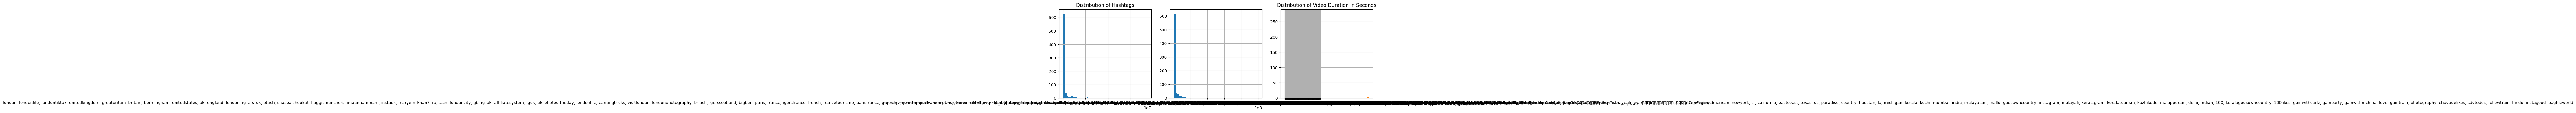

In [7]:
#distribution of columns

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

df["likes"].hist(bins=50, ax=axes[0])
axes[0].set_title("Distribution of Likes")

df["views"].hist(bins=50, ax=axes[1])
axes[0].set_title("Distribution of Views")

df["hashtags"].hist(bins=50, ax=axes[2])
axes[0].set_title("Distribution of Hashtags")

df["duration_seconds"].hist(bins=50, ax=axes[2])
axes[2].set_title("Distribution of Video Duration in Seconds")

plt.tight_layout()
plt.show()

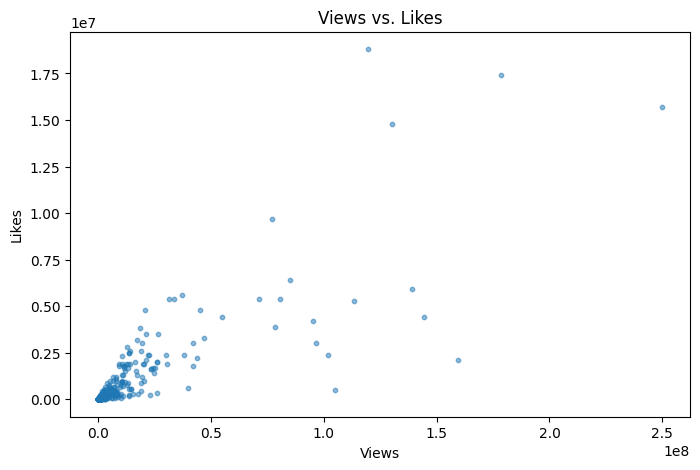

In [8]:
# Creating likes vs. views data scatter plot visualization
plt.figure(figsize=(8, 5))
plt.scatter(df["views"], df["likes"], alpha=0.5, s=10)
plt.xlabel("Views")
plt.ylabel("Likes")
plt.title("Views vs. Likes")
plt.show()

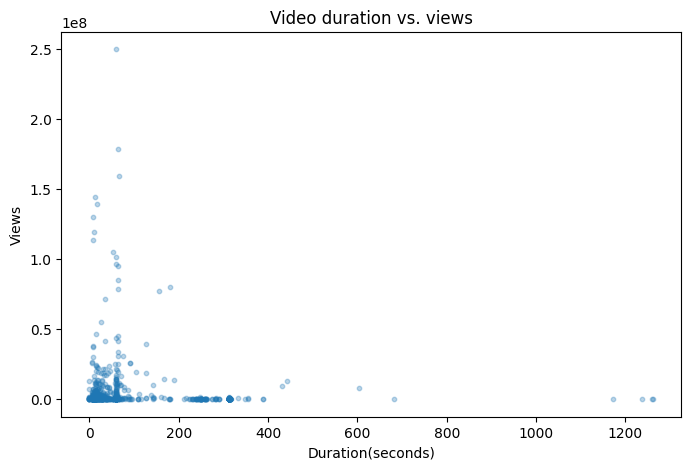

In [9]:
plt.figure(figsize=(8, 5))
plt.scatter(df["duration_seconds"], df["views"], alpha=0.3, s=10)
plt.xlabel("Duration(seconds)")
plt.ylabel("Views")
plt.title("Video duration vs. views")
plt.show()

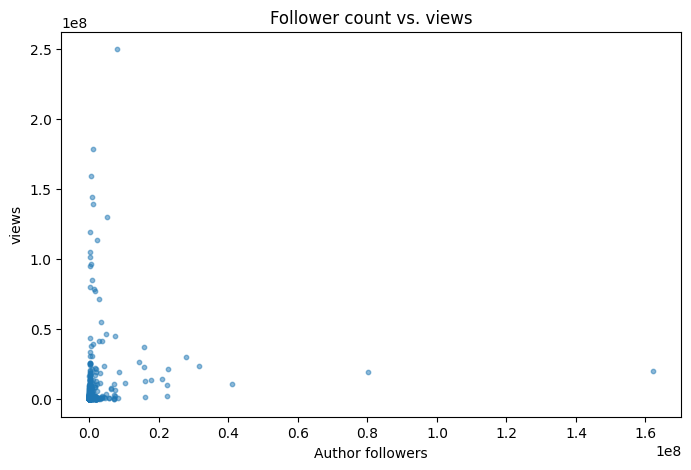

In [10]:
plt.figure(figsize=(8, 5))
plt.scatter(df["author_followers"], df["views"], alpha=0.5, s=10)
plt.xlabel("Author followers")
plt.ylabel("views")
plt.title("Follower count vs. views")
plt.show()

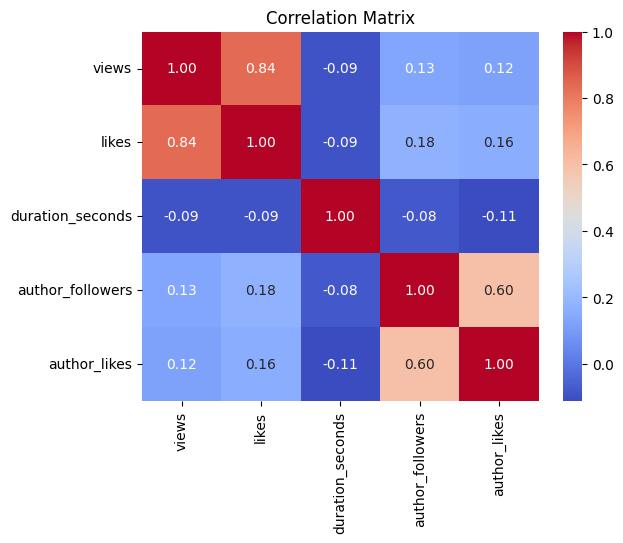

In [11]:
num_cols = df[["views", "likes", "duration_seconds", "author_followers", "author_likes"]].dropna()
sns.heatmap(num_cols.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

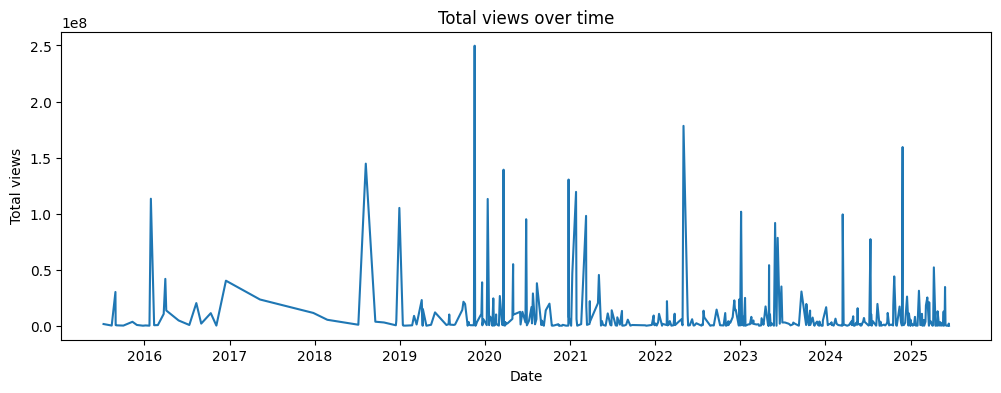

In [12]:
df_time = df.dropna(subset=["human_time"]).copy()
df_time["human_time"] = pd.to_datetime(df_time["human_time"], errors="coerce")
df_time.groupby(df_time["human_time"].dt.date)["views"].sum().plot(figsize=(12, 4))
plt.title("Total views over time")
plt.xlabel("Date")
plt.ylabel("Total views")
plt.show()

In [14]:
##DATA FINDINGS
#-Views and Likes**: strongly correlated
#- Duration**: defines whether short/long videos have more views
#- Follower count**: how much follower count drives traction in views
